# Mapas Tendencias
***
Esté código busca representar las tendencias medias por cuencas usando la máscara creada en la carpeta CreaCuencas. Para ello se usan los ficheros tendecy obtenidos en calcula tendencia y guardados en ./Data/tendency/ y se promedia las tendencias por cuencas. Para ellos los pasos a seguir son los siguientes:
1. Abrir el fichero con las tendencias
2. Calcular el promedio por máscara
3. Representar

Como características añadidas se ha puesto una variable que permite decidir si usar una mediana o una media para las tendencias por cuencas. Durante las prácticas se decidio que lo correcto era la media, ya que era más significativa estadísticamente. Una forma de comprobar esto es en las últimas celdas del script CalculaTendencias.ipynb, que representa las distribuciones de puntos y permite ver la agrupación de los mismos por los métodos de ajuste visto. 

Las imágenes que se obtienen de estos archivos están visibles en ./plots/Mapas_Tendencias/ donde el nombre resultante da información sobre la resolución, fechas y el método de ajuste.

In [ ]:
# Packages for data manipulation
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import median_abs_deviation

# Packages for representation
import matplotlib.pyplot as plt
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

# Package for progress bar
from tqdm import tqdm

# Ignore warnings
import warnings


warnings.filterwarnings('ignore', message='.*After omitting NaNs.*')
warnings.filterwarnings('ignore', message='.*After omitting NaNs.*')
warnings.filterwarnings('ignore', message='.*All-NaN slice encountered.*') 
warnings.filterwarnings('ignore', message='.*Degrees of freedom <= 0 for slice.*') 

In [ ]:
# Select resolution
resolution = '25'ç

# Date range
dates = '1990_2025'

# Pressure range
pressure_max = '5000'
pressure_min = '4000'

# Press code for saving
pressure_code = pressure_min[0] + pressure_max[0] + 'k'

# Select adjust method and mean or median
robust = True
median = False

# Define file name and figure name
if robust:
    file_name = f'tendency_{dates}_{resolution}_{pressure_code}_robust'
    fig_name = f'{dates}_{resolution}_{pressure_code}_robust'
    
else:
    file_name = f'tendency_{dates}_{resolution}_{pressure_code}'
    fig_name = f'{dates}_{resolution}_{pressure_code}'

### Apertura de los datos de tendencia y estructura

In [58]:
ds = xr.open_dataset(f'./Data/tendency/{file_name}.nc')
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (latitude: 563, longitude: 1355, n_prof: 78)
Coordinates:
  * latitude   (latitude) float64 5kB -77.75 -77.5 -77.25 ... 62.75 63.0 63.25
  * longitude  (longitude) float64 11kB -180.0 -179.8 -179.5 ... 179.8 180.0
    n          (latitude, longitude) float64 6MB ...
    batimetry  (latitude, longitude) float64 6MB ...
    mask       (latitude, longitude) float64 6MB ...
    basin      (latitude, longitude) <U18 55MB ...
    surface    (latitude, longitude) float64 6MB ...
  * n_prof     (n_prof) int64 624B 0 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
    times      (latitude, longitude, n_prof) datetime64[ns] 476MB ...
Data variables:
    profiles   (latitude, longitude, n_prof) float64 476MB ...
    tendency   (latitude, longitude) float64 6MB ...

Empezamos calculando la media y desviación por cuencas

In [ ]:
# Importing the unique values of the mask
cuencas = np.unique(ds.mask.values)

basin_idx = [] # Number of the basin
basin_mean = [] # Tendency mean asociated
basin_std = [] # Tendency std asociated

# Iterate for every 'cuenca'
for cuenca in cuencas:
    if np.isnan(cuenca): # Skip is cuenca is Nan
        continue

    else:
        tendency = ds.tendency.where(ds.mask == cuenca).values

        # Calculate the mean by the wanted method
        if median:
            tendency_mean = np.nanmedian(tendency)
            tendency_std = median_abs_deviation(tendency, axis = None, nan_policy = 'omit')
        else:
            tendency_mean = np.nanmean(tendency)
            tendency_std = np.nanstd(tendency)

        # Append values
        basin_idx.append(cuenca)
        basin_mean.append(tendency_mean)
        basin_std.append(tendency_std)

Una vez tenemos hechas las mismas, creamos un dataset con dos variables nuevas, tendency mean y std

In [60]:
# Load the values of lat, lon and mask
latitudes = ds.latitude.values
longitudes = ds.longitude.values
mask = ds.mask.values

# Creating empty matrix
tendency_mean = np.full((len(latitudes), len(longitudes)), np.nan)
tendency_std = np.full((len(latitudes), len(longitudes)), np.nan)

# Iterate for each basin
for k, basin in enumerate(basin_idx):
    tendency_mean = np.where(mask == basin, basin_mean[k], tendency_mean)
    tendency_std = np.where(mask == basin, basin_std[k], tendency_std)


In [61]:
# Adding the variable to dataset
ds['tendency_mean'] = (('latitude', 'longitude'), tendency_mean)
ds['tendency_std'] = (('latitude', 'longitude'), tendency_std)

## Mapa tendencias

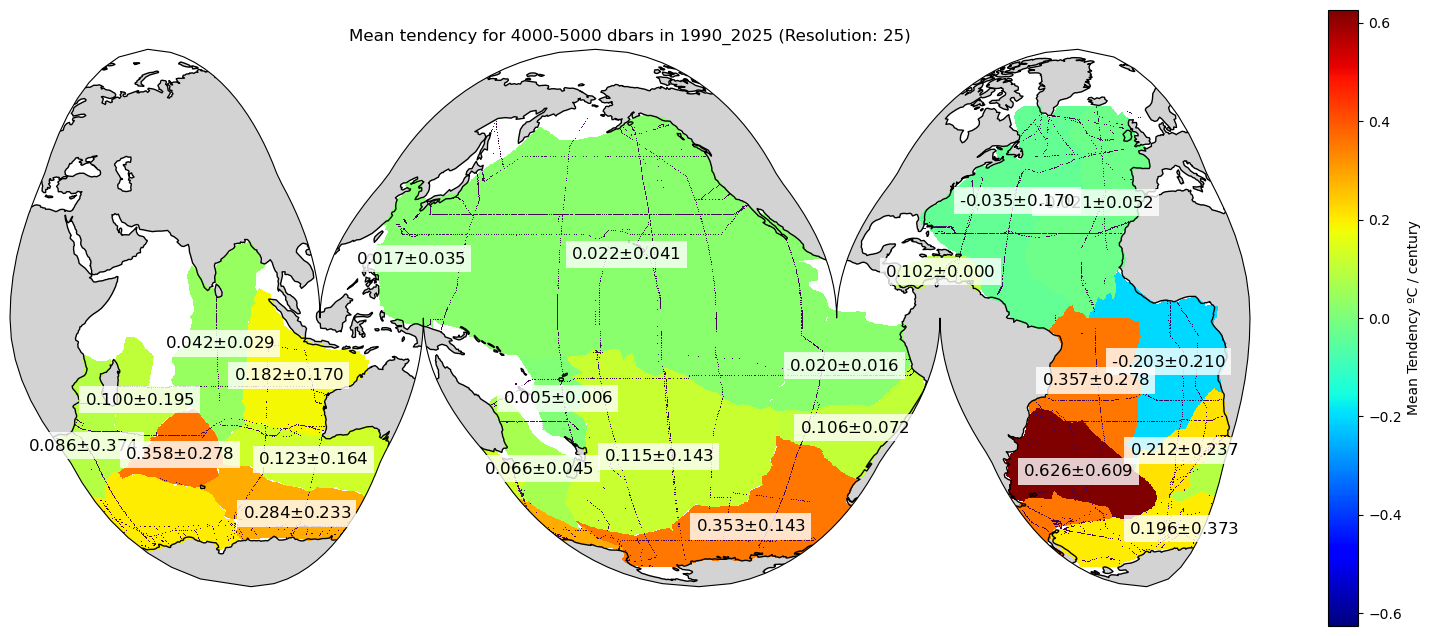

In [62]:
# Creating figure
fig, ax = plt.subplots(figsize=(20,10),
    subplot_kw={'projection': ccrs.InterruptedGoodeHomolosine(central_longitude=-160,emphasis='ocean')})

# Ploting mean
means = ds.tendency_mean.plot(ax = ax, cmap = "jet", transform = ccrs.PlateCarree(),  add_colorbar = False)

# Colorbar
fig.colorbar(mappable = means, shrink = 0.8, label = 'Mean Tendency ºC / century')

# Plotting ocupations
ds.n.plot(ax = ax, transform = ccrs.PlateCarree(), add_colorbar = False)

# Plotting features
ax.set_global()
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Title
ax.set_title(f'Mean tendency for {pressure_min}-{pressure_max} dbars in {dates} (Resolution: {resolution})')

# Plotting text
for k, basin in enumerate(basin_idx):
    if not np.isnan(basin_mean[k]):
        latitude = ds.latitude.where(ds.mask == basin).values
        longitude = ds.longitude.where(ds.mask == basin).values

        # Normal mean for latitude
        mean_lat = np.nanmean(latitude)

        # Ciruclar mean for longitude
        lon_rad = np.radians(longitude)
        mean_lon = np.degrees(np.arctan2(np.nanmean(np.sin(lon_rad)), np.nanmean(np.cos(lon_rad))))

        ax.text(mean_lon,mean_lat, rf'{basin_mean[k]:.3f}$\pm${basin_std[k]:.3f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0.8,edgecolor='none'))
    else:
        continue

# Save plot
if median:
    plt.savefig(f'./plots/Mapas_Tendencias/Mean_Tendency_{fig_name}_median.png')
else:
    plt.savefig(f'./plots/Mapas_Tendencias/Mean_Tendency_{fig_name}.png')

### Cerrar todos los archivos

In [63]:
ds.close()
plt.close('all')